<a href="https://colab.research.google.com/github/lybytes/st456-deep-learning-seminars/blob/main/w01_LinearRegression_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(LSE - ST456 DEEP LEARNING - WT2026)

(student version)

# Linear regression model

This notebook shows how to implement a **linear regression model** using **[Keras](https://www.tensorflow.org/guide/keras)**, which is considered a **high-level API** for machine and deep learning.

`[from the documentation]` Keras covers every step of the **machine learning workflow**, from data processing to hyperparameter tuning to deployment. It was developed with a focus on enabling fast experimentation.

The code is organised in **steps** mimicking a machine learning workflow (or pipeline), with some variations:

* setup: software installation and importing of necessary libraries
* data loading or generation
* exploratory data analysis and data preparation
* model implementation, performance check, and tuning
* interpretability and explainability of model results

We rely on `tf.keras.Model class` features built-in training and evaluation methods:

* `tf.keras.Model.compile`: used to configure the model.
* `tf.keras.Model.fit`: trains the model for a fixed number of epochs.
* `tf.keras.Model.predict`: generates output predictions for the input samples.
* `tf.keras.Model.evaluate`: returns the loss and metrics values for the model.

**Comparative analysis**: check Moodle and GitHub for an alternative implementation of a linear regression model based on the [TensorFlow Core APIs](https://www.tensorflow.org/guide/core), which allows for building complex models with high levels of configurability and targeting high-performance (distributed and accelerated) computation.




---


## Notes for running this code on Google Colab

* We don't need hardware accelerators for now. Notebook settings (Edit menu) can be leave as is (default option = `None`).
* We won't be using examples from any reference books for now. Just *standard* examples from the Tensorflow documentation and common practice.

---

## Step 1: software setup

In [ ]:
# TensorFlow is our main frawework for deep learning
import tensorflow as tf
# data visualisation
import matplotlib.pyplot as plt
%matplotlib inline
# data generation
import random


---

## Step 2: synthetic data creation

To keep things simple, we will **construct an artificial dataset
according to a linear model with additive noise.**
Our task will be to recover this model's parameters
using the finite set of examples contained in our dataset.
We will keep the data low-dimensional so we can visualize it easily.

In the following code snippet, we generate a dataset
containing 1,000 examples, each consisting of 2 features
sampled from a standard normal distribution.
Thus our synthetic dataset will be a matrix
$\mathbf{X}\in \mathbb{R}^{1000 \times 2}$.

**The true parameters generating our dataset will be
$\mathbf{w} = [2, -3.4]^\top$ and $b = 4.2$**,
and our synthetic labels will be assigned according
to the following linear model with the noise term $\epsilon$:

**$$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon.$$**

You could think of $\epsilon$ as capturing potential
measurement errors on the features and labels.
We will assume that the standard assumptions hold and thus
that $\epsilon$ obeys a normal distribution with mean of 0.
To make our problem easy, we will set its standard deviation to 0.01.

The following code generates our synthetic dataset.


In [ ]:
# synthetic data generation function
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    # tensor initialised with zeros
    X = tf.zeros((num_examples, w.shape[0]))
    # initial features (values) from random distribution
    X += tf.random.normal(shape=X.shape)
    # dot product X and w plus bias
    y = tf.matmul(X, tf.reshape(w, (-1, 1))) + b
    # add noise
    y += tf.random.normal(shape=y.shape, stddev=0.01)
    # reshape
    y = tf.reshape(y, (-1, 1))
    return X, y

In [ ]:
# setting parameters (w, b)
true_w = tf.constant([2, -3.4])
true_b = 4.2
# generating the dataset with 1,000 samples
features, labels = synthetic_data(true_w, true_b, 1000)
# checking the dataset structure (first 10 samples)
for i in range(10):
  print('features:', features[i], '\nlabel:', labels[i])

features: tf.Tensor([-0.15494902 -1.0267822 ], shape=(2,), dtype=float32) 
label: tf.Tensor([7.393678], shape=(1,), dtype=float32)
features: tf.Tensor([-0.33149764 -1.262334  ], shape=(2,), dtype=float32) 
label: tf.Tensor([7.844823], shape=(1,), dtype=float32)
features: tf.Tensor([-0.37753022  0.21722633], shape=(2,), dtype=float32) 
label: tf.Tensor([2.7104478], shape=(1,), dtype=float32)
features: tf.Tensor([-0.67979246  0.3446488 ], shape=(2,), dtype=float32) 
label: tf.Tensor([1.6793572], shape=(1,), dtype=float32)
features: tf.Tensor([-0.36000073  0.1539538 ], shape=(2,), dtype=float32) 
label: tf.Tensor([2.9536457], shape=(1,), dtype=float32)
features: tf.Tensor([ 0.21559262 -0.4339123 ], shape=(2,), dtype=float32) 
label: tf.Tensor([6.116082], shape=(1,), dtype=float32)
features: tf.Tensor([ 0.32437578 -0.91423696], shape=(2,), dtype=float32) 
label: tf.Tensor([7.967075], shape=(1,), dtype=float32)
features: tf.Tensor([-1.646125   1.6002207], shape=(2,), dtype=float32) 
label: 

Note that **each row in `features` consists of a 2-dimensional data example
and that each row in `labels` consists of a 1-dimensional label value (a scalar).**


Linear correlation between the second feature (`features[:, 1]`) and `labels`.


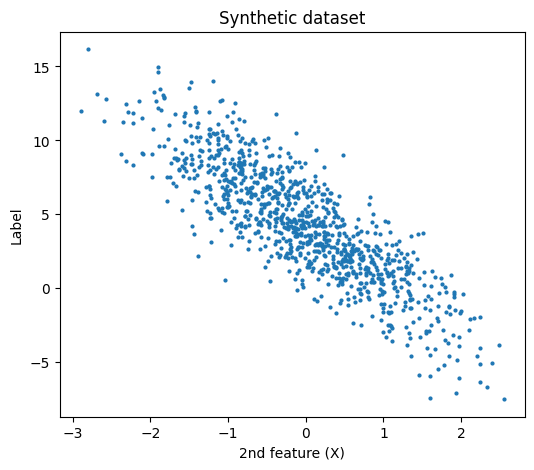

In [ ]:
# plotting the dataset for visualisation
# feel free to change the figsize
fig = plt.figure(figsize=(6, 5))
# parameters are: X feature, Y label, size of data points (feel free to change it)
plt.scatter(features[:, (1)].numpy(), labels.numpy(), 4)
plt.title("Synthetic dataset")
plt.xlabel("2nd feature (X)")
plt.ylabel("Label")
plt.show()

---

## Step 3: linear regression model

In this section, we implement the linear regression model concisely by using **high-level APIs** (`data`, `keras`, `initializers` etc) from TensorFlow.

We also provide an alternative implementation based on the *Core API* (tensors, auto differentiation for gradient calculation etc) in case you want to experiment with a more detailed code (check the Homework section). In practice, because data iterators, loss functions, optimisers, and neural network layers are so common, modern libraries, such as Tensorflow, implement these components for us.


### 3.1: defining the model

In the implementation based on the Core API, we implemented a linear regression model from scratch - we explicitly defined the model parameters and coded up the calculations to produce output using basic linear algebra operations. But once your models get more complex and you have to do this nearly every day, you will be glad for the assistance.

We can use the **[Sequential](https://keras.io/guides/sequential_model/)** class, which is a container for several layers chained together. Given input data (`X`), a `Sequential` instance passes it through the first layer, in turn passing the output as the second layer's input and so forth, until we get the output (`Y`). We can use **predefined layers**, which allow us to focus especially on the layers needed to construct the model rather than on their implementation.

In [ ]:
# To see this figure, download it from the GitHub repo 'fig' folder, upload it into Colab, and then uncomment the following lines.
#from IPython.display import Image
#Image(filename='./w01_fig2_1.png', width='500')

In the following example, we first define a model variable (e.g., `model`) to refer to an instance of the `Sequential` class. Our model is quite simple (only one layer), so we do not really need `Sequential`. But since nearly all of our future models
will involve multiple layers, we will use it anyway just to familiarise you
with the most standard workflow.

Recall the architecture of a single-layer network. The layer is said to be **fully-connected** because each of its inputs is connected to each of its outputs by means of a matrix-vector multiplication.

In [ ]:
# To see this figure, download it from the GitHub repo 'fig' folder, upload it into Colab, and then uncomment the following lines.
#from IPython.display import Image
#Image(filename='./w01_fig2_2.png', width='500')


In Keras' `Sequential` model, the **fully-connected layer** is defined in the **`Dense` class**. So, we add this layer to our model. Since we only want to generate a single scalar output, we set the output to 1.

It is worth noting that, for convenience, Keras does not require us to specify the input shape for each layer.
So here, we do not need to tell Keras how many inputs go into this linear layer. When we first try to pass data through our model, e.g., when we execute `model(X)` later, Keras will infer the number of inputs to each layer. We will describe how this works in more detail later.


In [ ]:
# baseline model
# YOUR CODE HERE

### 3.2: initialising model parameters

Before using the model, we need to **initialise the model parameters**,
such as the *weights* and *bias* in the linear regression model.

Deep learning frameworks have a predefined way to initialise the parameters. Here we specify that each weight parameter
should be randomly sampled from a normal distribution with mean 0 and standard deviation 0.01. The bias parameter will be initialised to zero.

The [initializers module in TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/initializers) provides various methods for model parameter initialization. The easiest way to specify the initialization method in Keras when creating the layer is by specifying `kernel_initializer`. Here we recreate `model`, adding the initializer.

In [ ]:
# specify an initialiser for the model
# YOUR CODE HERE
# recreate the model given the initialiser
# YOUR CODE HERE

There is an important aspect regarding the above code: we are initialising parameters for a network
even though Keras does not yet know
how many dimensions the input will have!
It might be 2 as in our example or it might be 2000.

Keras lets us get away with this because, behind the scenes,
the **initialisation is actually deferred**.
The real initialisation will take place only
when we, for the first time, attempt to pass data through the network.
**Be careful**: remember that since the parameters
have not been initialised yet,
we cannot access or manipulate them.

### 3.3: defining the loss function

The `MeanSquaredError` class computes the mean squared error (known as squared $L_2$ norm). By default it returns the average loss over examples.

Check other options in the [tf.keras.losses](https://www.tensorflow.org/api_docs/python/tf/keras/losses) module.

In [ ]:
# loss function
# YOUR CODE HERE

### 3.4: defining the optimisation algorithm

Minibatch stochastic gradient descent is a standard tool
for optimising neural networks
and thus Keras supports it alongside a number of
variations on this algorithm in the [optimizers module](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers).

Minibatch stochastic gradient descent just requires that
we set the value `learning_rate`, which is set to 0.03 here.

In [ ]:
# optimisation method.
# YOUR CODE HERE

### 3.5: compiling (building) the model

Once you have defined the optimisation method (or optimiser) and the loss function, the next step is to compile (or build) the model.


In [ ]:
# model compilation
# YOUR CODE HERE

### 3.6: training the model

You might have noticed that expressing our model through
high-level APIs of a deep learning framework
requires comparatively few lines of code.
We did not have to individually allocate parameters,
define our loss function, or implement minibatch stochastic gradient descent.
Once we start working with much more complex models,
advantages of high-level APIs will grow considerably.

For training the model, we rely on the `fit()` method. We need to specify the following parameters:

* **training features and labels**, usually referred as to `X` and `y` (and variations, such as `X_train` and `y_train`).
* **batch size**: the number of data points in a single batch passed through the neural network.
* **epochs**: the number of training steps. Each epoch is made up of batches. The total number of batches needed to complete one epoch is called *iteration* (see [here](https://www.educative.io/answers/what-is-the-difference-between-epoch-batch-size-and-iteration))

In [ ]:
# training the model
# YOUR CODE HERE

Epoch 1/50
22/22 - 0s - loss: 9.2697e-05 - val_loss: 8.8903e-05 - 348ms/epoch - 16ms/step
Epoch 2/50
22/22 - 0s - loss: 9.2521e-05 - val_loss: 8.9037e-05 - 71ms/epoch - 3ms/step
Epoch 3/50
22/22 - 0s - loss: 9.2631e-05 - val_loss: 8.8700e-05 - 68ms/epoch - 3ms/step
Epoch 4/50
22/22 - 0s - loss: 9.2648e-05 - val_loss: 8.8985e-05 - 68ms/epoch - 3ms/step
Epoch 5/50
22/22 - 0s - loss: 9.2646e-05 - val_loss: 8.8795e-05 - 68ms/epoch - 3ms/step
Epoch 6/50
22/22 - 0s - loss: 9.2709e-05 - val_loss: 8.8920e-05 - 84ms/epoch - 4ms/step
Epoch 7/50
22/22 - 0s - loss: 9.2710e-05 - val_loss: 8.8595e-05 - 70ms/epoch - 3ms/step
Epoch 8/50
22/22 - 0s - loss: 9.2673e-05 - val_loss: 8.8974e-05 - 73ms/epoch - 3ms/step
Epoch 9/50
22/22 - 0s - loss: 9.2584e-05 - val_loss: 8.8856e-05 - 74ms/epoch - 3ms/step
Epoch 10/50
22/22 - 0s - loss: 9.2913e-05 - val_loss: 8.8956e-05 - 68ms/epoch - 3ms/step
Epoch 11/50
22/22 - 0s - loss: 9.2655e-05 - val_loss: 8.9178e-05 - 65ms/epoch - 3ms/step
Epoch 12/50
22/22 - 0s - los

---

## 4. Interpretability and performance check

In this section, we try to understand **what is happening behind the scenes**.

First, we can check the **structure of our model** by invoking the `summary()` method. This method shows the number and type of each layer, and how many trainable and non-trainable (if any) parameters exist in each layer.


In [ ]:
# checking the model structure/summary
# YOUR CODE HERE

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 3         
                                                                 
Total params: 3 (12.00 Byte)
Trainable params: 3 (12.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



Then, we can check the **final state of our model**, i.e., the last values of `W` and `b`. For doing that, we can access the layer that we need from the model and then access that layer's weights and bias.




In [ ]:
# retrieving information on layers and corresponding weights
for layer in model.layers:
  print('Layer: ', layer)
  print('Weights: ', layer.get_weights())

Layer:  <keras.src.layers.core.dense.Dense object at 0x78cf444fba90>
Weights:  [array([[ 2.000137],
       [-3.400252]], dtype=float32), array([4.199873], dtype=float32)]


Finally, we can **check the model performance**: we can **compare the model parameters learnt by training on finite data and the actual parameters (`𝐰=[2,−3.4]` and `𝑏=4.2`) that generated our dataset**.

We note that our estimated parameters are close to their ground-truth counterparts.

In [ ]:
# Comparing model performance against the gold standard
w = model.get_weights()[0]
print('Error in estimating w:', true_w - tf.reshape(w, true_w.shape))
b = model.get_weights()[1]
print('Error in estimating b:', true_b - b)

Error in estimating w: tf.Tensor([-0.00013709  0.00025201], shape=(2,), dtype=float32)
Error in estimating b: [0.00012684]


---

### Summary

* Using TensorFlow's high-level APIs, we can implement models much more concisely (if compared to any core/low-level implementation).
* In TensorFlow, the `data` module provides tools for data processing and the `keras` module defines a large number of neural network layers and common loss functions.
* TensorFlow's module `initializers` provides various methods for parameter initialization.
* Dimensionality and storage are automatically inferred.
* Be careful not to attempt to access parameters or model structure before they have been initialised.
